In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation
import numpy as np
import os
import re

In [2]:
# Import dataset as anndata object

dir = "/rds/general/user/ztb25/home/PBMC_datasets/5/"

adata = sc.read_10x_mtx(
    dir,
    var_names="gene_symbols",
    cache=False
)

adata.var_names_make_unique()

# not sure why but here wouldnt load unless features had 3 cols (previously only 2 required?). Added feature_types column with just 'Gene Expression'

In [ ]:
adata

AnnData object with n_obs × n_vars = 105081 × 36601
    var: 'gene_ids', 'feature_types'

In [ ]:
display(adata.obs.head())
display(adata.var.head()) 

""
DM029P_PD_MX1_AAACCTGAGAGGACGG-1
DM024P_MSA_MX1_AAACCTGAGAGTAATC-1
DM029P_PD_MX1_AAACCTGAGCTAACAA-1
DM009C_CTRL_MX1_AAACCTGAGCTGTTCA-1
DM006C_CTRL_MX1_AAACCTGCAATCAGAA-1


,gene_ids,feature_types
MIR1302-2HG,MIR1302-2HG,Gene Expression
FAM138A,FAM138A,Gene Expression
OR4F5,OR4F5,Gene Expression
AL627309.1,AL627309.1,Gene Expression
AL627309.3,AL627309.3,Gene Expression


In [5]:
pd.DataFrame(
    adata.X[:10, :20].toarray(),
    index=adata.obs_names[:10],
    columns=adata.var_names[:20]
)

,MIR1302-2HG,FAM138A,OR4F5,AL627309.1,AL627309.3,AL627309.2,AL627309.5,AL627309.4,AP006222.2,AL732372.1,OR4F29,AC114498.1,OR4F16,AL669831.2,LINC01409,FAM87B,LINC01128,LINC00115,FAM41C,AL645608.6
DM029P_PD_MX1_AAACCTGAGAGGACGG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DM024P_MSA_MX1_AAACCTGAGAGTAATC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DM029P_PD_MX1_AAACCTGAGCTAACAA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DM009C_CTRL_MX1_AAACCTGAGCTGTTCA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DM006C_CTRL_MX1_AAACCTGCAATCAGAA-1,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DM024P_MSA_MX1_AAACCTGCACACCGAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DM029P_PD_MX1_AAACCTGCATCCGTGG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DM024P_MSA_MX1_AAACCTGGTCCGACGT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DM006C_CTRL_MX1_AAACCTGGTCGCATAT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DM006C_CTRL_MX1_AAACCTGGTCTAGCCG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# import (already given) metadata

metadata = pd.read_csv("PBMC_datasets/5/metadata.csv")
metadata = metadata.set_index("Unnamed: 0")

metadata.head()

,orig.ident,simpl_ID,soup_ID_simpl,Donor,PaperDonor,Group,Sex,Age,nCount_RNA,nFeature_RNA,...,Simplified_Idents,ASG_Score1,VDJ_barcode,CTgene,CTnt,CTaa,CTstrict,Frequency,cloneType,Monocle3_clusters
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
DM029P_PD_MX1_AAACCTGAGAGGACGG-1,MX1,MX1_AAACCTGAGAGGACGG-1,E,DM029P,PD3,PD,M,65,7477,2743,...,Monocytes,0.692682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Activated CD14 Monocytes
DM024P_MSA_MX1_AAACCTGAGAGTAATC-1,MX1,MX1_AAACCTGAGAGTAATC-1,D,DM024P,MSA1,MSA,M,63,20047,4174,...,Dendritic cells,0.162691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DM029P_PD_MX1_AAACCTGAGCTAACAA-1,MX1,MX1_AAACCTGAGCTAACAA-1,E,DM029P,PD3,PD,M,65,4667,1950,...,NK cells,1.178492,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DM009C_CTRL_MX1_AAACCTGAGCTGTTCA-1,MX1,MX1_AAACCTGAGCTGTTCA-1,A,DM009C,CTRL10,CTRL,M,52,7322,2084,...,T cells,0.920603,DM009C_CTRL_MX1_AAACCTGAGCTGTTCA-1_CTRL_DM009C,NA_TRBV29-1..TRBJ1-4.TRBC1,NA_TGCAGCGTTGGCGACGGAGTTTCGGGTGAAAAACTGTTTTTT,NA_CSVGDGVSGEKLFF,NA_NA_TRBV29-1..TRBJ1-4.TRBC1_TGCAGCGTTGGCGACG...,1.0,Single (0 < X <= 1),NaN
DM006C_CTRL_MX1_AAACCTGCAATCAGAA-1,MX1,MX1_AAACCTGCAATCAGAA-1,B,DM006C,CTRL5,CTRL,F,72,7842,2742,...,Monocytes,1.040138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CD14 Monocytes


In [8]:
# Take out cols we need from metadata

metadata_to_merge = metadata[["orig.ident", "simpl_ID", "soup_ID_simpl", "Donor", "PaperDonor", "Group", "Sex", "Age", "nCount_RNA", "nFeature_RNA", "percent.mt", "predicted.celltype.l1", "predicted.celltype.l1.score", "predicted.celltype.l2", "predicted.celltype.l2.score", "scibet", "final_anno", "final_broad", "Simplified_Idents"]]
metadata_to_merge

# looks like multiple (6) multiplexed runs/batches (orig.ident), each with 5 samples 

,orig.ident,simpl_ID,soup_ID_simpl,Donor,PaperDonor,Group,Sex,Age,nCount_RNA,nFeature_RNA,percent.mt,predicted.celltype.l1,predicted.celltype.l1.score,predicted.celltype.l2,predicted.celltype.l2.score,scibet,final_anno,final_broad,Simplified_Idents
Unnamed: 0,,,,,,,,,,,,,,,,,,,
DM029P_PD_MX1_AAACCTGAGAGGACGG-1,MX1,MX1_AAACCTGAGAGGACGG-1,E,DM029P,PD3,PD,M,65,7477,2743,2.353885,Mono,1.000000,CD14 Mono,1.000000,CD14_mono,CD14_CD83_mono,CD14 mono,Monocytes
DM024P_MSA_MX1_AAACCTGAGAGTAATC-1,MX1,MX1_AAACCTGAGAGTAATC-1,D,DM024P,MSA1,MSA,M,63,20047,4174,4.419614,DC,1.000000,cDC2,1.000000,DC2,DC2,cDC,Dendritic cells
DM029P_PD_MX1_AAACCTGAGCTAACAA-1,MX1,MX1_AAACCTGAGCTAACAA-1,E,DM029P,PD3,PD,M,65,4667,1950,3.471181,NK,1.000000,NK,1.000000,ILC1_3,NK_16hi,NK cells,NK cells
DM009C_CTRL_MX1_AAACCTGAGCTGTTCA-1,MX1,MX1_AAACCTGAGCTGTTCA-1,A,DM009C,CTRL10,CTRL,M,52,7322,2084,3.714832,CD4 T,0.899919,CD4 TCM,0.825277,CD4.IL22,CD4_IL22,CD4 T cells,T cells
DM006C_CTRL_MX1_AAACCTGCAATCAGAA-1,MX1,MX1_AAACCTGCAATCAGAA-1,B,DM006C,CTRL5,CTRL,F,72,7842,2742,2.754399,Mono,1.000000,CD14 Mono,1.000000,CD83_CD14_mono,CD14_CD83_mono,CD14 mono,Monocytes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Prat_2020_10_CTRL_MX6_TTTGTCATCGGATGTT-1,MX6,MX6_TTTGTCATCGGATGTT-1,A,Prat_2020_10,CTRL1,CTRL,F,82,2450,1204,1.469388,Mono,1.000000,CD14 Mono,1.000000,Mono_prolif,CD14_mono,CD14 mono,Monocytes
Prat_2020_10_CTRL_MX6_TTTGTCATCGTAGGTT-1,MX6,MX6_TTTGTCATCGTAGGTT-1,A,Prat_2020_10,CTRL1,CTRL,F,82,6360,2307,4.371069,Mono,1.000000,CD16 Mono,1.000000,CD16_mono,CD16_mono,CD16 mono,Monocytes
Prat_2020_10_CTRL_MX6_TTTGTCATCTCGCATC-1,MX6,MX6_TTTGTCATCTCGCATC-1,A,Prat_2020_10,CTRL1,CTRL,F,82,7077,2370,4.705384,Mono,0.970842,CD16 Mono,0.970842,CD16_mono,CD16_mono,CD16 mono,Monocytes


In [9]:
# merge metadata with adata.obs

adata.obs = adata.obs.join(metadata, how="left") # align to adata cells (keeps adata order)


In [10]:
# filter for only CTRL and PD samples

adata = adata[adata.obs["Group"].isin(["CTRL", "PD"])]
print(adata)

# check how many participants of each type (control vs parkinsons) we have

adata.obs.groupby("Group")["Donor"].nunique()

View of AnnData object with n_obs × n_vars = 78876 × 36601
    obs: 'orig.ident', 'simpl_ID', 'soup_ID_simpl', 'Donor', 'PaperDonor', 'Group', 'Sex', 'Age', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_SCT', 'nFeature_SCT', 'percent.mt', 'predicted.celltype.l1', 'predicted.celltype.l1.score', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'scibet', 'final_anno', 'final_broad', 'Simplified_Idents', 'ASG_Score1', 'VDJ_barcode', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'Frequency', 'cloneType', 'Monocle3_clusters'
    var: 'gene_ids', 'feature_types'


Group
CTRL    10
PD      14
Name: Donor, dtype: int64

In [11]:
# rename some column names for consistency with other datasets 

adata.obs = adata.obs.rename(columns={"Group": "diagnosis"})
adata.obs = adata.obs.rename(columns={"PaperDonor": "sample"})
adata.obs = adata.obs.rename(columns={"Sex": "gender"})
adata.obs = adata.obs.rename(columns={"Age": "age"})

adata

AnnData object with n_obs × n_vars = 78876 × 36601
    obs: 'orig.ident', 'simpl_ID', 'soup_ID_simpl', 'Donor', 'sample', 'diagnosis', 'gender', 'age', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_SCT', 'nFeature_SCT', 'percent.mt', 'predicted.celltype.l1', 'predicted.celltype.l1.score', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'scibet', 'final_anno', 'final_broad', 'Simplified_Idents', 'ASG_Score1', 'VDJ_barcode', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'Frequency', 'cloneType', 'Monocle3_clusters'
    var: 'gene_ids', 'feature_types'

In [12]:
# calculate proportions of samples in age bands (50-59, 60-69, 70-79, 80+), for age-matching with control dataset

# extract from obs, one row per sample with age and diagnosis
sample_ages = adata.obs[["sample", "age", "diagnosis"]].drop_duplicates(subset="sample").copy()
sample_ages["age"] = pd.to_numeric(sample_ages["age"], errors="coerce")

# define age bands (include a 45-50 bin for this dataset)
bins = [39, 49, 59, 69, 79, 200]
labels = ["40-50", "50-59", "60-69", "70-79", "80+"]

sample_ages["age_band"] = pd.cut(sample_ages["age"], bins=bins, labels=labels, right=True, include_lowest=True)

# overall counts and proportions of samples per age band
age_band_counts = sample_ages["age_band"].value_counts().reindex(labels, fill_value=0)
age_band_props = (age_band_counts / age_band_counts.sum()).round(3)
age_band_counts = pd.DataFrame({"count": age_band_counts, "proportion": age_band_props})

display(age_band_counts)

# proportions by diagnosis (only interested in AD)
by_diag_counts = sample_ages.groupby(["diagnosis", "age_band"]).size().unstack(fill_value=0).reindex(columns=labels, fill_value=0)
by_diag_prop = by_diag_counts.div(by_diag_counts.sum(axis=1), axis=0).round(3)

display(by_diag_counts)
display(by_diag_prop)

# save proprtions per age band by diagnosis
out_path = "/rds/general/user/ztb25/home/PBMC_datasets/5/age_band_props_by_diagnosis.csv"
by_diag_counts.to_csv(out_path)

,count,proportion
40-50,0,0.000
50-59,1,0.042
60-69,16,0.667
70-79,5,0.208
80+,2,0.083


age_band,40-50,50-59,60-69,70-79,80+
diagnosis,,,,,
CTRL,0,1,6,1,2
PD,0,0,10,4,0


age_band,40-50,50-59,60-69,70-79,80+
diagnosis,,,,,
CTRL,0.0,0.1,0.600,0.100,0.2
PD,0.0,0.0,0.714,0.286,0.0


In [13]:
# calculate gender counts, overall and by diagnosis

gender_counts = adata.obs.drop_duplicates("sample")["gender"].value_counts()
gender_by_diag_counts = adata.obs.drop_duplicates("sample").groupby("diagnosis")["gender"].value_counts().unstack(fill_value=0)

display(gender_counts)
display(gender_by_diag_counts)

# samples, not cells


M    12
F    12
Name: gender, dtype: int64

gender,F,M
diagnosis,,
CTRL,5,5
PD,7,7


In [12]:
# Run QC globally

# Annotate mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")  

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"], 
    percent_top=[20],
    log1p=True,
    inplace=True
)

adata # to check new metadata cols

AnnData object with n_obs × n_vars = 78876 × 36601
    obs: 'orig.ident', 'simpl_ID', 'soup_ID_simpl', 'Donor', 'sample', 'diagnosis', 'gender', 'age', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_SCT', 'nFeature_SCT', 'percent.mt', 'predicted.celltype.l1', 'predicted.celltype.l1.score', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'scibet', 'final_anno', 'final_broad', 'Simplified_Idents', 'ASG_Score1', 'VDJ_barcode', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'Frequency', 'cloneType', 'Monocle3_clusters', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

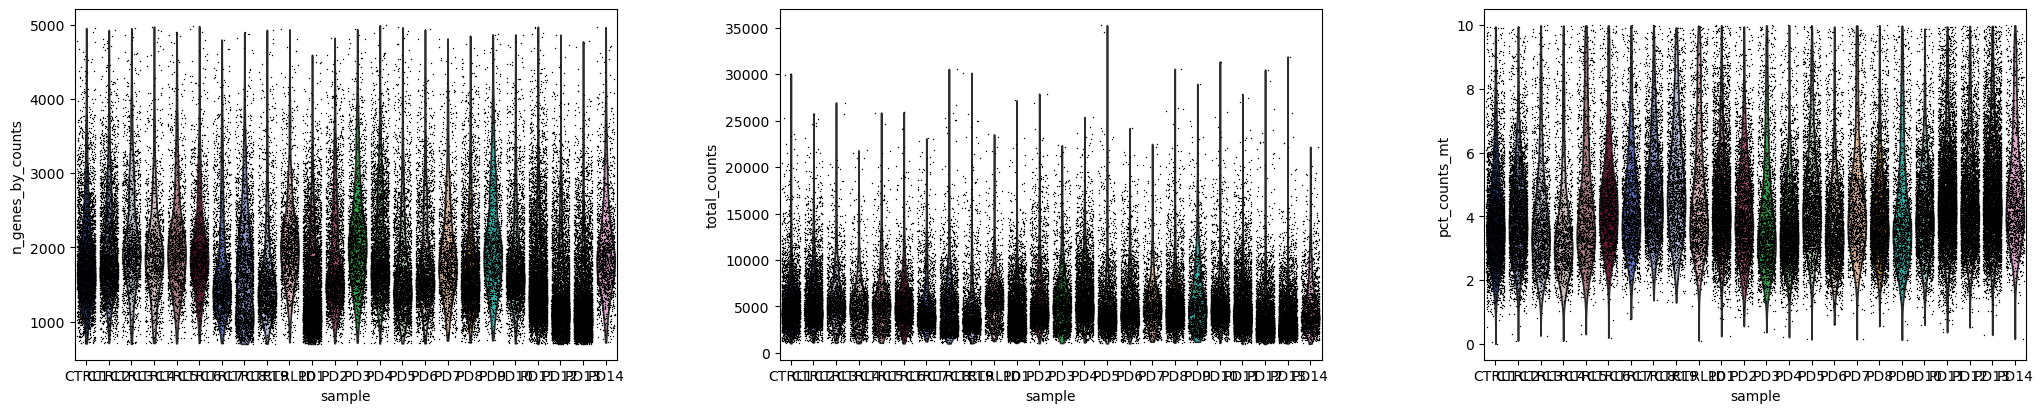

In [13]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    groupby="sample",
    jitter=0.4,
    multi_panel=True
)

# looks like data is filtered (harsh mito percent cutoff)

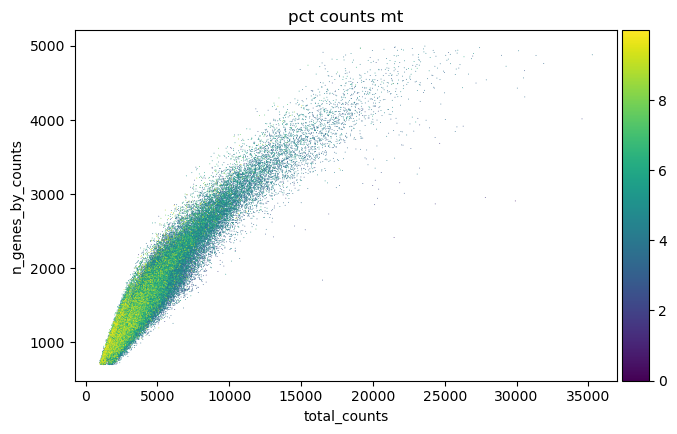

In [14]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [15]:
# QC already done (according to paper): 
# cells with high or low feature count (<700 and > 5000) and high mitochondrial content (>10%) were filtered out
# doublet removal

# preprocessing left to do (from my pipeline):
# filtering out uninformative genes, normalisation, log transforming, feature selection

In [16]:
# Filter out genes not detected in at least 20 cells (not informative)

print(f"Total number of genes: {adata.n_vars}")

# Min 20 cells - filters out 0 count genes
sc.pp.filter_genes(adata, min_cells=20)
print(f"Number of genes after cell filter: {adata.n_vars}")

Total number of genes: 36601
Number of genes after cell filter: 20053


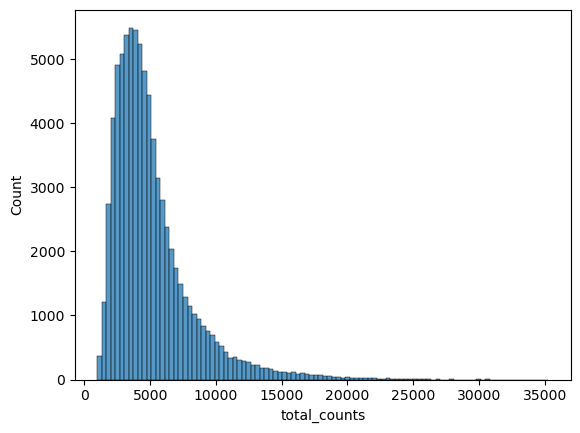

In [17]:
##### Normalisation ##### ----------------------------------------------------------------------------------------------------

# inspect distribution of the raw counts
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)

In [18]:
# Method 1: Shifted logarithm (sc-best practice)

scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False) #changes not made to adata.X
# log1p transform and add to layer
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True) 

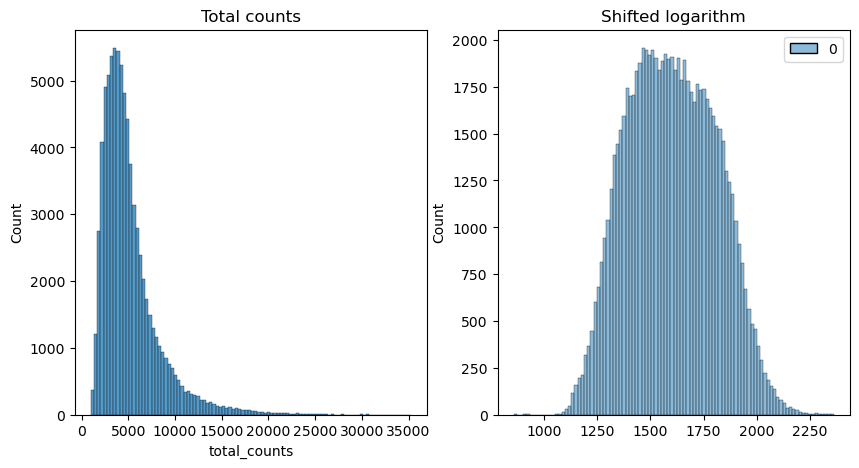

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

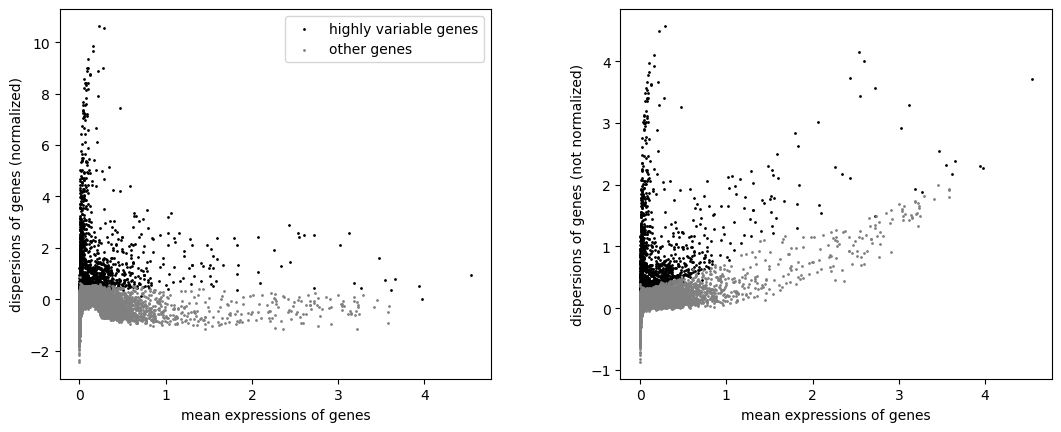

In [20]:
##### Feature Selection ##### ----------------------------------------------------------------------------------------------------
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample", layer = "log1p_norm") # automatically adds columns to adata.var 'highly_variable', 'means', 'dispersions', 'dispersions_norm'. Downstream functions like pca will automatically use only the HVGs if use_highly_variable=True is passed.
sc.pl.highly_variable_genes(adata)

# Mean expression is simply the average expression level of a gene across all cells — how highly expressed it is on average.
# Dispersion is a measure of how much a gene's expression varies across cells, normalized for its mean.

In [21]:
# Save final dataset for integration

adata.write("/rds/general/user/ztb25/home/PBMC_datasets/5/PBMC5_preprocessed.h5ad")